Chọn hành động với DQN tối giản
Hàm select_action() cho phép agent chọn hành động có Q-value cao nhất ở mỗi bước.

Hàm nhận Q-network và trạng thái hiện tại làm đối số, và trả về chỉ số của hành động có Q-value cao nhất.

Q-network đã được khởi tạo là q_network, và một trạng thái ngẫu nhiên đã được nạp trong môi trường của bạn với state = torch.rand(8) để cung cấp dữ liệu ví dụ cho bạn thực hành.

Hướng dẫn
100 XP
Tính các Q-value tương ứng với mỗi hành động trong trạng thái được truyền vào làm đối số.
Lấy chỉ số tương ứng với hành động có Q-value cao nhất.

In [ ]:
def select_action(q_network, state):
    # Calculate the Q-values
    q_values = ____
    print("Q-values:", [round(x, 2) for x in q_values.tolist()])
    # Obtain the action index with highest Q-value
    action = torch.____.item()
    print(f"Action selected: {action}, with q-value {q_values[action]:.2f}")
    return action

select_action(q_network, state)

In [ ]:
"""
def select_action(q_network, state):
    # Calculate the Q-values
    q_values = q_network(state)
    print("Q-values:", [round(x, 2) for x in q_values.tolist()])
    # Obtain the action index with highest Q-value
    action = torch.argmax(q_values).item()
    print(f"Action selected: {action}, with q-value {q_values[action]:.2f}")
    return action

select_action(q_network, state)
"""

Hàm mất mát DQN bản tối giản
Với hàm select_action() đã sẵn sàng, bạn chỉ còn một bước nữa là có thể huấn luyện agent: bây giờ bạn sẽ hiện thực calculate_loss().

Hàm calculate_loss() trả về giá trị mất mát của mạng tại một bước bất kỳ trong episode.

Tham khảo, công thức mất mát được cho bởi:

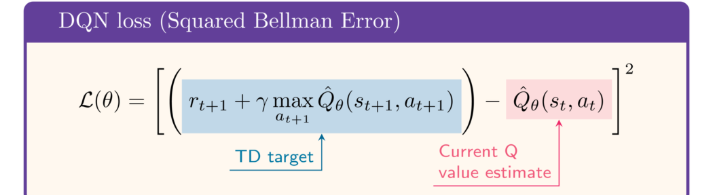

Ví dụ dữ liệu sau đã được nạp sẵn trong bài tập:

state = torch.rand(8)

next_state = torch.rand(8)

action = select_action(q_network, state)


reward = 1

gamma = .99

done = False

Hướng dẫn
100 XP
Lấy Q-value của trạng thái hiện tại.
Lấy Q-value của trạng thái kế tiếp.
Tính Q-value mục tiêu (TD-target).
Tính hàm mất mát, tức là Sai số Bellman bình phương.

In [ ]:
def calculate_loss(q_network, state, action, next_state, reward, done):
    q_values = q_network(state)
    print(f'Q-values: {q_values}')
    # Obtain the current state Q-value
    current_state_q_value = q_values[____]
    print(f'Current state Q-value: {current_state_q_value:.2f}')
    # Obtain the next state Q-value
    next_state_q_value = q_network(next_state).____    
    print(f'Next state Q-value: {next_state_q_value:.2f}')
    # Calculate the target Q-value
    target_q_value = ____ + gamma * ____ * (1-done)
    print(f'Target Q-value: {target_q_value:.2f}')
    # Obtain the loss
    loss = nn.MSELoss()(____, ____)
    print(f'Loss: {loss:.2f}')
    return loss

calculate_loss(q_network, state, action, next_state, reward, done)

In [ ]:
"""
def calculate_loss(q_network, state, action, next_state, reward, done):
    q_values = q_network(state)
    print(f'Q-values: {q_values}')
    # Obtain the current state Q-value
    current_state_q_value = q_values[action]
    print(f'Current state Q-value: {current_state_q_value:.2f}')
    # Obtain the next state Q-value
    next_state_q_value = q_network(next_state).max()    
    print(f'Next state Q-value: {next_state_q_value:.2f}')
    # Calculate the target Q-value
    target_q_value = reward + gamma * next_state_q_value * (1-done)
    print(f'Target Q-value: {target_q_value:.2f}')
    # Obtain the loss
    loss = nn.MSELoss()(current_state_q_value, target_q_value)
    print(f'Loss: {loss:.2f}')
    return loss

calculate_loss(q_network, state, action, next_state, reward, done)
"""

Huấn luyện DQN bản tối giản
Đến lúc huấn luyện thuật toán DQN bản tối giản trong môi trường Lunar Lander. Hãy nhớ rằng đây vẫn chỉ là phiên bản cơ bản, nên hiệu suất sẽ chưa cao — nhưng bạn sẽ cải thiện dần ở phần sau.

Hãy coi đây là bước khởi đầu để đưa tàu Lunar Lander hạ cánh lên Mặt Trăng!

Thực thể q_network mà bạn đã định nghĩa trước đó hiện có sẵn để sử dụng.

Xuyên suốt các bài tập trong khóa học, môi trường Python của bạn cũng kèm theo hàm describe_episode() để in ra một số thông tin ở cuối mỗi episode về mức độ hoạt động của agent.

Hướng dẫn
100 XP
Chọn hành động của agent trong vòng lặp bên trong.
Tính toán loss.
Thực hiện một bước gradient descent để cập nhật trọng số của mạng.

In [1]:
for episode in range(10):
    state, info = env.reset()
    done = False
    step = 0
    episode_reward = 0
    while not done:
        step += 1     
        # Select the action
        action = ____(____, ____)
        next_state, reward, terminated, truncated, _ = (env.step(action))
        done = terminated or truncated
        # Calculate the loss
        loss = ____(q_network, state, action, next_state, reward, done)
        optimizer.zero_grad()
        # Perform a gradient descent step
        loss.____
        optimizer.____
        state = next_state
        episode_reward += reward
    describe_episode(episode, reward, episode_reward, step)

NameError: name 'env' is not defined

In [ ]:
"""
for episode in range(10):
    state, info = env.reset()
    done = False
    step = 0
    episode_reward = 0
    while not done:
        step += 1     
        # Select the action
        action = select_action(q_network, state)
        next_state, reward, terminated, truncated, _ = (env.step(action))
        done = terminated or truncated
        # Calculate the loss
        loss = calculate_loss(q_network, state, action, next_state, reward, done)
        optimizer.zero_grad()
        # Perform a gradient descent step
        loss.backward()
        optimizer.step()
        state = next_state
        episode_reward += reward
    describe_episode(episode, reward, episode_reward, step)
    """